In [28]:
import numpy as np
import matplotlib.pyplot as plt

from Triangle.Constants import * 
from Triangle.GW import * 
from Triangle.FFTTools import *
from Triangle.Noise import *
from Triangle.Orbit import *
from Triangle.TDI import *

In [29]:
wave_data = np.loadtxt("/Users/taijidatacenter/Downloads/0105.txt")
wave_data.shape 

(2097152, 3)

In [30]:
wave_data[1, 0] - wave_data[0, 0], wave_data[-1, 0] / YEAR

(15.0, 0.996803210444798)

In [31]:
waveform_generator = General_Injection(
    t_data=wave_data[:, 0], 
    hp_data=wave_data[:, 1],
    hc_data=wave_data[:, 2],
)


In [32]:
orbit = Orbit(
    OrbitDir="/Users/taijidatacenter/workspace/Triangle-Simulator/OrbitData/TaijiEqualArmOrbit", 
    dt=DAY, 
    pn_order=0, 
)

response_generator = FastMichelsonTDIResponse(
    orbit=orbit, 
    tcb_times=wave_data[:, 0].copy(), 
    use_gpu=False, 
    drop_points=int(1000/(wave_data[1, 0] - wave_data[0, 0])), 
    interp_method="Spline5", 
)

In [33]:
tdi = response_generator(
    parameters={
        "longitude": 2.232796975919999927e+00, 
        "latitude": np.pi / 2. - 4.989444892403920306e-01, 
    }, 
    waveform_generator=waveform_generator, 
    optimal_combination="True", 
)

tdi.shape 

(3, 2097152)

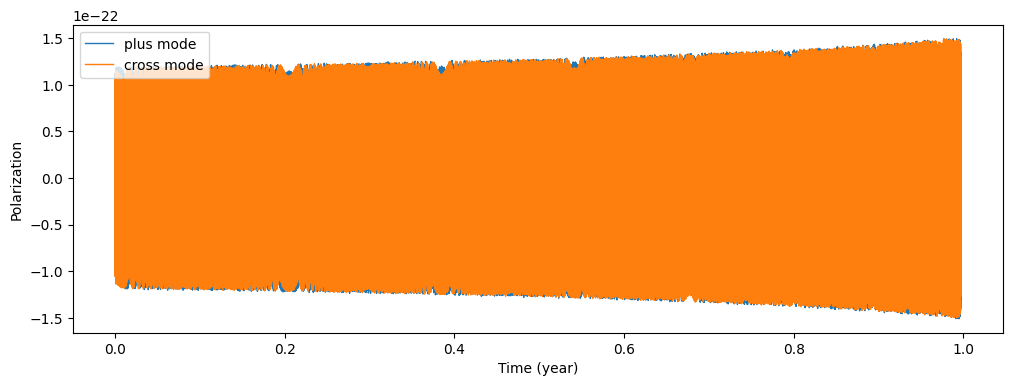

In [34]:
plt.figure(figsize=(12, 4))
plt.plot(wave_data[:, 0]/YEAR, wave_data[:, 1], linewidth=1, label="plus mode")
plt.plot(wave_data[:, 0]/YEAR, wave_data[:, 2], linewidth=1, label="cross mode")
plt.xlabel("Time (year)")
plt.ylabel("Polarization")
plt.legend(loc="upper left")

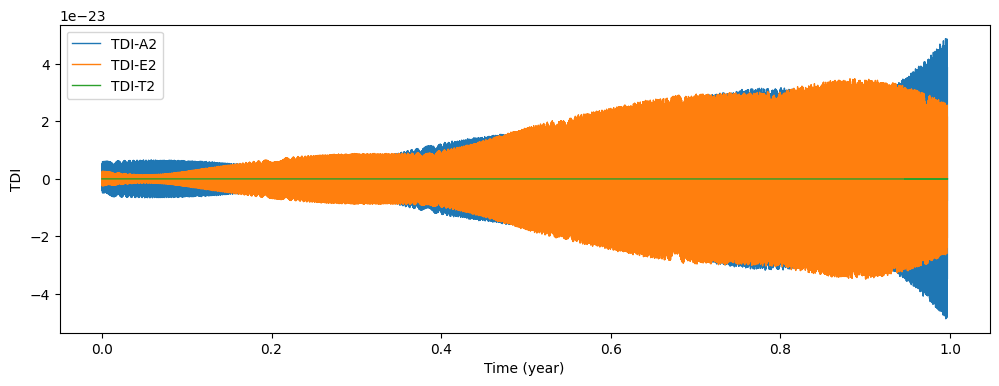

In [35]:
plt.figure(figsize=(12, 4))
plt.plot(wave_data[:, 0]/YEAR, tdi[0], linewidth=1, label="TDI-A2")
plt.plot(wave_data[:, 0]/YEAR, tdi[1], linewidth=1, label="TDI-E2")
plt.plot(wave_data[:, 0]/YEAR, tdi[2], linewidth=1, label="TDI-T2")
plt.xlabel("Time (year)")
plt.ylabel("TDI")
plt.legend(loc="upper left")

(1e-23, 6.598068119234249e-18)

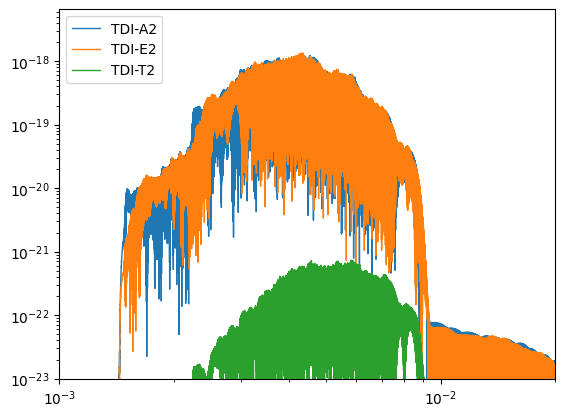

In [36]:
ff, xf = FFT_window(
    data_array=tdi[0], 
    fsample=1./(wave_data[1, 0] - wave_data[0, 0]), 
    window_type="tukey",
    window_args_dict=dict(alpha=0.1), 
)
plt.loglog(ff, np.abs(xf), linewidth=1, label="TDI-A2")

ff, xf = FFT_window(
    data_array=tdi[1], 
    fsample=1./(wave_data[1, 0] - wave_data[0, 0]), 
    window_type="tukey",
    window_args_dict=dict(alpha=0.1), 
)
plt.loglog(ff, np.abs(xf), linewidth=1, label="TDI-E2")

ff, xf = FFT_window(
    data_array=tdi[2], 
    fsample=1./(wave_data[1, 0] - wave_data[0, 0]), 
    window_type="tukey",
    window_args_dict=dict(alpha=0.1), 
)
plt.loglog(ff, np.abs(xf), linewidth=1, label="TDI-T2")

plt.legend(loc="upper left")
plt.xlim(1e-3, 0.02)
plt.ylim(1e-23,)

In [37]:
np.savetxt(
    fname="/Users/taijidatacenter/Downloads/0105TDI.txt", 
    X=np.array([wave_data[:, 0], tdi[0], tdi[1]]).T,
    header="Time (s) | TDI-A2 | TDI-E2"
)